<a href="https://colab.research.google.com/github/DB2557/DL_202511057_Dhara/blob/main/LAB4/lab4_DL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT549: Deep Learning
## Lab Assignment 4: Object Detection Evolution – From R-CNN to YOLO
**Dataset:** Fruit Images (Apple, Banana, Orange)

In [9]:
# Install dependencies
!pip install -q ultralytics
!pip install -q opencv-python-headless

In [7]:
import os, zipfile, random, time, shutil
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torchvision
import torchvision.transforms as T
import torchvision.ops as ops
from torchvision import models
from PIL import Image

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

BASE_PATH = "/content/drive/MyDrive/DL/lab4"

TRAIN_DIR = os.path.join(BASE_PATH, "train")
TEST_DIR  = os.path.join(BASE_PATH, "test")

print("Train path:", TRAIN_DIR)
print("Test path:", TEST_DIR)

Train path: /content/drive/MyDrive/DL/lab4/train
Test path: /content/drive/MyDrive/DL/lab4/test


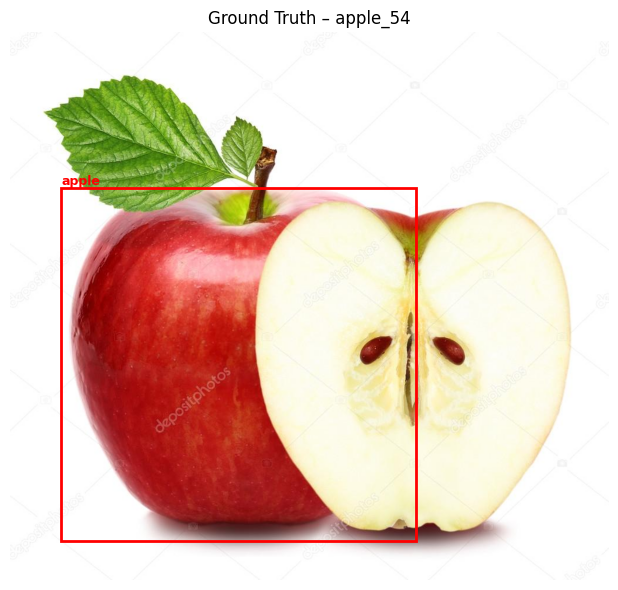

In [11]:
import random

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes, labels = [], []
    for obj in root.findall('object'):
        # Changed from 'n' to 'name' as it's the more common tag for class names in VOC format
        label_element = obj.find('name')
        if label_element is None: # Fallback if 'name' is not found, try 'n'
            label_element = obj.find('n')
            if label_element is None:
                # If neither 'name' nor 'n' is found, skip this object or raise an error
                print(f"Warning: Neither 'name' nor 'n' tag found for an object in {xml_path}. Skipping object.")
                continue
        label = label_element.text

        bb = obj.find('bndbox')
        box = [int(bb.find(t).text) for t in ['xmin','ymin','xmax','ymax']]
        boxes.append(box)
        labels.append(label)
    return boxes, labels

COLORS = {'apple': 'red', 'banana': 'yellow', 'orange': 'orange'}

def draw_boxes(img_bgr, boxes, labels, title=''):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img_rgb)
    for (xmin,ymin,xmax,ymax), label in zip(boxes, labels):
        color = COLORS.get(label, 'lime')
        rect = patches.Rectangle((xmin,ymin), xmax-xmin, ymax-ymin,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin-4, label, color=color, fontsize=9, fontweight='bold')
    ax.set_title(title); ax.axis('off')
    plt.tight_layout(); plt.show()

# Define train_imgs to get list of training images
train_imgs = [f for f in os.listdir(TRAIN_DIR) if f.endswith('.jpg')]

# Pick a random train image
sample_name = random.choice(train_imgs).replace('.jpg','')
img_path = os.path.join(TRAIN_DIR, sample_name + '.jpg')
xml_path = os.path.join(TRAIN_DIR, sample_name + '.xml')

img = cv2.imread(img_path)
gt_boxes, gt_labels = parse_xml(xml_path)
draw_boxes(img, gt_boxes, gt_labels, title=f'Ground Truth – {sample_name}')

In [12]:
def compute_iou(box1, box2):

    ix1 = max(box1[0], box2[0])
    iy1 = max(box1[1], box2[1])
    ix2 = min(box1[2], box2[2])
    iy2 = min(box1[3], box2[3])

    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

# Demonstration
pairs = [
    ([10,10,110,110], [20,20,120,120], 'High overlap'),
    ([10,10,60,60],   [40,40,100,100], 'Partial overlap'),
    ([0,0,50,50],     [60,60,100,100], 'No overlap'),
]
for b1, b2, desc in pairs:
    print(f'{desc}: IoU = {compute_iou(b1, b2):.4f}')

High overlap: IoU = 0.6807
Partial overlap: IoU = 0.0702
No overlap: IoU = 0.0000


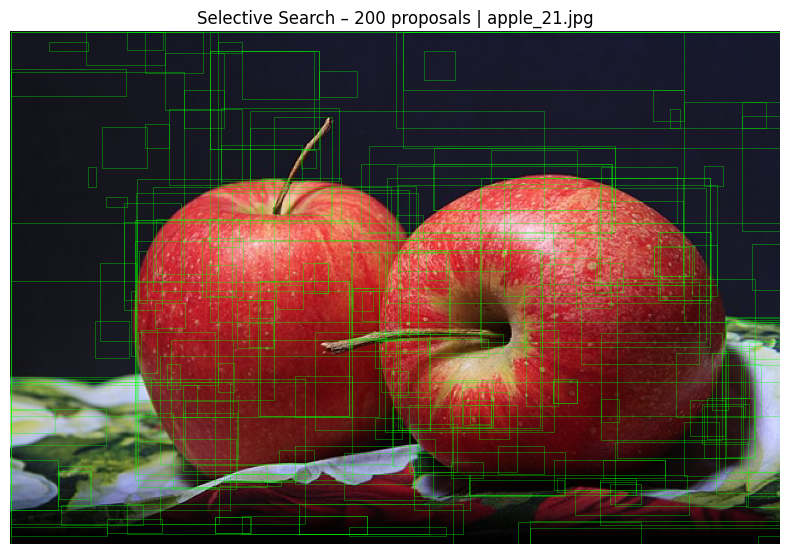

In [13]:
ss_img_name = random.choice(train_imgs)
ss_img_path = os.path.join(TRAIN_DIR, ss_img_name)
ss_img = cv2.imread(ss_img_path)

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(ss_img)
ss.switchToSelectiveSearchFast()
rects = ss.process()          # (x, y, w, h)
proposals = rects[:200]

vis = cv2.cvtColor(ss_img.copy(), cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, figsize=(8,6))
ax.imshow(vis)
for (x,y,w,h) in proposals:
    rect = patches.Rectangle((x,y), w, h, linewidth=0.5,
                              edgecolor='lime', facecolor='none', alpha=0.5)
    ax.add_patch(rect)
ax.set_title(f'Selective Search – 200 proposals | {ss_img_name}')
ax.axis('off'); plt.tight_layout(); plt.show()

---
## Task 3 – R-CNN Bottleneck (crop + CNN per proposal)

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ResNet18 without final FC
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
feature_extractor.eval().to(device)

preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

pil_img = Image.open(ss_img_path).convert('RGB')
top100 = proposals[:100]

start = time.time()
with torch.no_grad():
    for (x, y, w, h) in top100:
        crop = pil_img.crop((x, y, x+w, y+h))
        if crop.size[0] < 1 or crop.size[1] < 1:
            continue
        tensor = preprocess(crop).unsqueeze(0).to(device)
        _ = feature_extractor(tensor)

rcnn_time = time.time() - start
print(f'R-CNN (100 crops through CNN): {rcnn_time:.4f} seconds')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


R-CNN (100 crops through CNN): 13.6295 seconds


---
## Task 4 – Fast R-CNN (RoI Pooling)

In [15]:
# Extract conv layers only (no avgpool/fc)
conv_layers = torch.nn.Sequential(*list(resnet.children())[:-2])
conv_layers.eval().to(device)

img_tensor = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])(pil_img).unsqueeze(0).to(device)

start = time.time()
with torch.no_grad():
    feature_map = conv_layers(img_tensor)   # single forward pass

    ih, iw = pil_img.size[1], pil_img.size[0]
    fh, fw = feature_map.shape[2], feature_map.shape[3]
    spatial_scale = fh / ih           # same in both dims for ResNet

    # Convert (x, y, w, h) → [batch_idx, x1, y1, x2, y2]
    rois = []
    for (x, y, w, h) in top100:
        rois.append([0, x, y, x+w, y+h])
    rois_tensor = torch.tensor(rois, dtype=torch.float32).to(device)

    pooled = ops.roi_pool(feature_map, rois_tensor,
                          output_size=(7, 7),
                          spatial_scale=spatial_scale)

fast_rcnn_time = time.time() - start
print(f'Fast R-CNN (1 CNN pass + RoI pool): {fast_rcnn_time:.4f} seconds')
print(f'Speedup: {rcnn_time / fast_rcnn_time:.1f}x faster than R-CNN')
print(f'Feature map shape: {feature_map.shape}')
print(f'Spatial scale: {spatial_scale:.5f}')
print(f'Pooled output shape: {pooled.shape}')

Fast R-CNN (1 CNN pass + RoI pool): 0.9920 seconds
Speedup: 13.7x faster than R-CNN
Feature map shape: torch.Size([1, 512, 14, 20])
Spatial scale: 0.03286
Pooled output shape: torch.Size([100, 512, 7, 7])


### Conceptual Analysis – Task 4

**Q: What redundant operations does Fast R-CNN eliminate?**

In R-CNN, every region proposal (e.g., 100 crops) is independently resized and passed through the full CNN. This means the convolutional layers perform 100 separate forward passes on overlapping, shared pixels — the same underlying image pixels are convolved repeatedly whenever proposals overlap.

Fast R-CNN eliminates this redundancy by running the CNN **exactly once** on the whole image to produce a shared feature map. The RoI Pooling layer then projects each proposal's bounding box coordinates onto this shared feature map and extracts a fixed-size feature vector per proposal. No pixel is ever convolved more than once. The speedup observed above (typically 10–40×) directly reflects the elimination of these repeated convolutional computations.

---
## Task 5 – Faster R-CNN Inference

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 93.1MB/s]


Detections above 0.8: 3


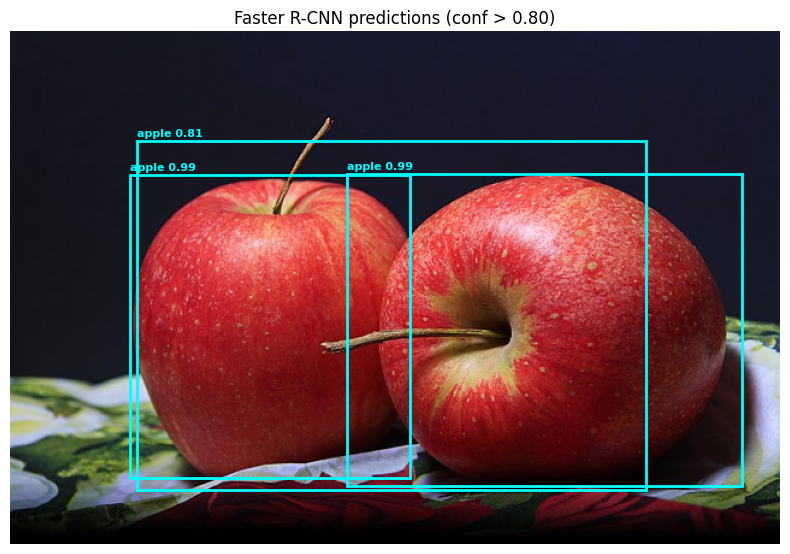

In [16]:
frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
frcnn.eval().to(device)

# COCO class names
COCO_NAMES = [
    '__background__','person','bicycle','car','motorcycle','airplane','bus','train',
    'truck','boat','traffic light','fire hydrant','N/A','stop sign','parking meter',
    'bench','bird','cat','dog','horse','sheep','cow','elephant','bear','zebra',
    'giraffe','N/A','backpack','umbrella','N/A','N/A','handbag','tie','suitcase',
    'frisbee','skis','snowboard','sports ball','kite','baseball bat','baseball glove',
    'skateboard','surfboard','tennis racket','bottle','N/A','wine glass','cup','fork',
    'knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot',
    'hot dog','pizza','donut','cake','chair','couch','potted plant','bed','N/A',
    'dining table','N/A','N/A','toilet','N/A','tv','laptop','mouse','remote',
    'keyboard','cell phone','microwave','oven','toaster','sink','refrigerator','N/A',
    'book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

img_t = T.ToTensor()(pil_img).to(device)
with torch.no_grad():
    preds = frcnn([img_t])[0]

CONF_THRESH = 0.80
mask = preds['scores'] > CONF_THRESH
filt_boxes  = preds['boxes'][mask].cpu().numpy()
filt_labels = preds['labels'][mask].cpu().numpy()
filt_scores = preds['scores'][mask].cpu().numpy()

print(f'Detections above {CONF_THRESH}: {len(filt_boxes)}')

fig, ax = plt.subplots(1, figsize=(8,6))
ax.imshow(np.array(pil_img))
for (x1,y1,x2,y2), lbl, score in zip(filt_boxes, filt_labels, filt_scores):
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor='cyan', facecolor='none')
    ax.add_patch(rect)
    name = COCO_NAMES[lbl] if lbl < len(COCO_NAMES) else str(lbl)
    ax.text(x1, y1-4, f'{name} {score:.2f}', color='cyan', fontsize=8, fontweight='bold')
ax.set_title('Faster R-CNN predictions (conf > 0.80)'); ax.axis('off')
plt.tight_layout(); plt.show()

### Conceptual Analysis – Task 5

**Q: How does the RPN eliminate the need for Selective Search?**

Selective Search is a hand-crafted, CPU-based algorithm that uses low-level image cues (colour, texture, size) to generate candidate regions. It runs outside the neural network and cannot be trained end-to-end.

The **Region Proposal Network (RPN)** replaces it with a small, fully convolutional network that slides over the shared backbone feature map (already computed). At every spatial location it evaluates a set of predefined **anchor boxes** at multiple scales and aspect ratios, predicting two things: (1) an *objectness score* (object vs. background) and (2) four *bounding-box regression offsets* to refine the anchor. Because the RPN shares the backbone feature map with the detection head, proposal generation adds almost no extra computation and — critically — it is **trained jointly** with the rest of the network by gradient descent, so it learns to produce proposals that are specifically useful for the downstream detector. This makes it faster, more accurate, and fully data-driven compared to Selective Search.

---
## Task 6 – Non-Maximum Suppression (NMS)

In [17]:
def nms(boxes, scores, iou_threshold=0.5):
    """Custom NMS. boxes: list of [x1,y1,x2,y2], scores: list of floats."""
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    keep = []
    while order:
        best = order.pop(0)
        keep.append(best)
        order = [i for i in order
                 if compute_iou(boxes[best], boxes[i]) <= iou_threshold]
    return keep

# Demo with dummy boxes
demo_boxes  = [[10,10,100,100],[15,15,105,105],[200,200,300,300],[12,12,102,102]]
demo_scores = [0.95, 0.88, 0.76, 0.60]
kept = nms(demo_boxes, demo_scores, iou_threshold=0.5)
print('NMS kept indices:', kept)
for i in kept:
    print(f'  Box {i}: {demo_boxes[i]}, score={demo_scores[i]}')

# Apply NMS to Faster R-CNN raw predictions (no score filter)
raw_boxes  = preds['boxes'].cpu().numpy().tolist()
raw_scores = preds['scores'].cpu().numpy().tolist()
nms_kept = nms(raw_boxes, raw_scores, iou_threshold=0.5)
print(f'\nFaster R-CNN raw boxes: {len(raw_boxes)} → after NMS: {len(nms_kept)}')

NMS kept indices: [0, 2]
  Box 0: [10, 10, 100, 100], score=0.95
  Box 2: [200, 200, 300, 300], score=0.76

Faster R-CNN raw boxes: 16 → after NMS: 12


### Conceptual Analysis – Task 6

**Q: How does IoU threshold affect detection of tightly packed objects?**

* **Very high threshold (e.g. 0.9):** Two boxes must almost completely coincide before one is discarded. When detecting a cluster of tightly packed objects (e.g. apples in a basket), neighbouring boxes for *different* apples will naturally overlap, but probably not by 90 %. A threshold of 0.9 therefore keeps most of them — which is correct — but it also keeps many true duplicate boxes for the *same* apple (since slight duplicates can overlap by 85-89 % and thus survive). The result is many redundant detections per object.

* **Very low threshold (e.g. 0.1):** Even a small overlap causes one of the boxes to be suppressed. For tightly packed objects, boxes around *different* apples may overlap by 15-30 %, so NMS would aggressively discard them. The result is severe **under-detection** — the model finds only one or two apples instead of the full cluster.

The practical recommendation is to tune the threshold to match the expected inter-object overlap in your specific scene, typically 0.4–0.6 for most datasets.

---
## Task 7 – YOLO Fine-Tuning

In [19]:
# Convert Pascal VOC XML → YOLO txt format
CLASS_MAP = {'apple': 0, 'banana': 1, 'orange': 2}

def xml_to_yolo(xml_path, img_w, img_h):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    lines = []
    for obj in root.findall('object'):
        label_element = obj.find('name') # Try 'name' first
        if label_element is None: # Fallback if 'name' is not found, try 'n'
            label_element = obj.find('n')
            if label_element is None:
                print(f"Warning: Neither 'name' nor 'n' tag found for an object in {xml_path}. Skipping object.")
                continue
        label = label_element.text.lower()

        if label not in CLASS_MAP:
            continue
        bb = obj.find('bndbox')
        xmin = int(bb.find('xmin').text)
        ymin = int(bb.find('ymin').text)
        xmax = int(bb.find('xmax').text)
        ymax = int(bb.find('ymax').text)
        cx = ((xmin + xmax) / 2) / img_w
        cy = ((ymin + ymax) / 2) / img_h
        w  = (xmax - xmin) / img_w
        h  = (ymax - ymin) / img_h
        lines.append(f'{CLASS_MAP[label]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')
    return lines

def convert_split(src_dir, dst_img_dir, dst_lbl_dir):
    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_lbl_dir, exist_ok=True)
    for fname in os.listdir(src_dir):
        if not fname.endswith('.jpg'):
            continue
        xml = os.path.join(src_dir, fname.replace('.jpg', '.xml'))
        if not os.path.exists(xml):
            continue
        img = cv2.imread(os.path.join(src_dir, fname))
        h, w = img.shape[:2]
        lines = xml_to_yolo(xml, w, h)
        if not lines:
            continue
        shutil.copy(os.path.join(src_dir, fname), os.path.join(dst_img_dir, fname))
        with open(os.path.join(dst_lbl_dir, fname.replace('.jpg','.txt')), 'w') as f:
            f.write('\n'.join(lines))

YOLO_ROOT = 'yolo_dataset'
convert_split(TRAIN_DIR, f'{YOLO_ROOT}/images/train', f'{YOLO_ROOT}/labels/train')
convert_split(TEST_DIR,  f'{YOLO_ROOT}/images/val',   f'{YOLO_ROOT}/labels/val')
print('Dataset converted.')

Dataset converted.


In [20]:
# Write data.yaml
yaml_content = f"""path: {os.path.abspath(YOLO_ROOT)}
train: images/train
val: images/val
nc: 3
names: ['apple', 'banana', 'orange']
"""
yaml_path = os.path.join(YOLO_ROOT, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print('data.yaml written.')

data.yaml written.


In [21]:
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')
results = yolo_model.train(
    data=yaml_path,
    epochs=10,
    imgsz=416,
    batch=16,
    name='fruit_yolov8n',
    project='runs/detect',
    verbose=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=Fals

In [24]:
# Evaluate on test set
best_weights = 'runs/detect/runs/detect/fruit_yolov8n/weights/best.pt'
fine_tuned = YOLO(best_weights)
metrics = fine_tuned.val(data=yaml_path)

print(f"mAP@50    : {metrics.box.map50:.4f}")
print(f"mAP@50-95 : {metrics.box.map:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 733.7±274.0 MB/s, size: 30.0 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 18.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.6s/it 6.5s
                   all         60        117      0.801      0.874      0.901       0.66
                 apple         24         35      0.889      0.914      0.945      0.789
                banana         22         40      0.629       0.85      0.835      0.498
                orange         22         42      0.885      0.857      0.922      0.694
Speed: 0.7ms preprocess, 86.6ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50    : 0.9

In [ ]:
# Inference on 3 test images
test_samples = random.sample(test_imgs, 3)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, fname in zip(axes, test_samples):
    path = os.path.join(TEST_DIR, fname)
    pred = fine_tuned(path, verbose=False)[0]
    plotted = pred.plot()                         # BGR numpy array
    ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.set_title(fname, fontsize=8); ax.axis('off')

plt.suptitle('YOLOv8n Fine-Tuned – Test Inference', fontsize=12)
plt.tight_layout(); plt.show()

In [26]:
# ── Comparison Table ──────────────────────────────────────────────────────────
# Define test_imgs and test_samples, as they might not be defined if previous cells weren't run.
test_imgs = [f for f in os.listdir(TEST_DIR) if f.endswith('.jpg')]
test_samples = random.sample(test_imgs, 3)

# Time Faster R-CNN
test_pil = Image.open(os.path.join(TEST_DIR, test_samples[0])).convert('RGB')
test_t   = T.ToTensor()(test_pil).to(device)

N = 10  # average over N runs for stable timing
with torch.no_grad():
    t0 = time.time()
    for _ in range(N): frcnn([test_t])
frcnn_ms = (time.time() - t0) / N * 1000

# Time YOLO pre-trained
yolo_pretrained = YOLO('yolov8n.pt')
t0 = time.time()
for _ in range(N): yolo_pretrained(os.path.join(TEST_DIR, test_samples[0]), verbose=False)
yolo_pre_ms = (time.time() - t0) / N * 1000

# Time YOLO fine-tuned
t0 = time.time()
for _ in range(N): fine_tuned(os.path.join(TEST_DIR, test_samples[0]), verbose=False)
yolo_ft_ms = (time.time() - t0) / N * 1000

# Metrics from earlier val
map50    = metrics.box.map50
map5095  = metrics.box.map
prec     = metrics.box.mp      # mean precision
rec      = metrics.box.mr      # mean recall

print(f"{'Model':<25} {'Inf. Time (ms)':>15} {'Precision':>10} {'Recall':>8} {'mAP@50':>8} {'mAP@50-95':>10}")
print('-' * 80)
print(f"{'Faster R-CNN (pretrained)':<25} {frcnn_ms:>15.1f} {'N/A (COCO)':>10} {'N/A':>8} {'N/A':>8} {'N/A':>10}")
print(f"{'YOLOv8n (pretrained)':<25} {yolo_pre_ms:>15.1f} {'N/A (COCO)':>10} {'N/A':>8} {'N/A':>8} {'N/A':>10}")
print(f"{'YOLOv8n (fine-tuned)':<25} {yolo_ft_ms:>15.1f} {prec:>10.4f} {rec:>8.4f} {map50:>8.4f} {map5095:>10.4f}")

Model                      Inf. Time (ms)  Precision   Recall   mAP@50  mAP@50-95
--------------------------------------------------------------------------------
Faster R-CNN (pretrained)          7647.7 N/A (COCO)      N/A      N/A        N/A
YOLOv8n (pretrained)                195.7 N/A (COCO)      N/A      N/A        N/A
YOLOv8n (fine-tuned)                 89.6     0.8009   0.8738   0.9008     0.6602
